We will now implement a chatbot that can asnwer questions based n a story given to the bot. 

We will use the BaBi dataset 
We are using a subset with stories, questions, adn answers. 

We will have stories / sentences like - 
Jane went to the store. Mike ran to the bedroom. 

Question - Is mike in the store? 

Answer - No. 

# End to End Memory network. 
- #### Input Memory Representation
- #### Output Memory Representation
- #### Generating Final PRediction

##### Then we can create full model with RNN and Multiple Layers 

we will have x - sotry, q - question, a - answers. 

We will have V - vocabulary. 

# Part One - 
- ## Load the data format 
- ## Explore the data format 
- ## Create a vocabulary 

In [2]:
import pickle
import numpy as np

In [3]:
with open("L:\\Workspace\\Resources\\UPDATED_NLP_COURSE\\06-Deep-Learning\\train_qa.txt", 'rb') as f:
    train_data = pickle.load(f)

In [4]:
with open("L:\\Workspace\\Resources\\UPDATED_NLP_COURSE\\06-Deep-Learning\\test_qa.txt", 'rb') as f:
    test_data = pickle.load(f)

In [5]:
type(test_data)

list

In [6]:
type(train_data)

list

In [7]:
len(train_data)

10000

In [8]:
len(test_data)

1000

In [9]:
train_data[0]

(['Mary',
  'moved',
  'to',
  'the',
  'bathroom',
  '.',
  'Sandra',
  'journeyed',
  'to',
  'the',
  'bedroom',
  '.'],
 ['Is', 'Sandra', 'in', 'the', 'hallway', '?'],
 'no')

In [12]:
print(f"Story - {train_data[0][0]}, \nQuestion - {train_data[0][1]} \nAnswer - {train_data[0][2]}")

Story - ['Mary', 'moved', 'to', 'the', 'bathroom', '.', 'Sandra', 'journeyed', 'to', 'the', 'bedroom', '.'], 
Question - ['Is', 'Sandra', 'in', 'the', 'hallway', '?'] 
Answer - no


We will first set up the vocabulary for whole data - train and test data together 

In [14]:
all_data = test_data + train_data 

In [58]:
len(all_data)

11000

### How to make a vocabulary?? 
- ##### Like this -

##### we will use add words to a set - so we will get unique elements.

In [42]:
vocab = set()
for story, question, answer in all_data :
    vocab = vocab.union(set(story))
    # This makes set of a story - and unions - meaning gets all the unique words from story and currently existing vocab, and adds to the set. 
    vocab = vocab.union(set(question))
    vocab.add(answer)

In [43]:
type(vocab)

set

In [44]:
len(vocab)

37

In [46]:
vocab

{'.',
 '?',
 'Daniel',
 'Is',
 'John',
 'Mary',
 'Sandra',
 'apple',
 'back',
 'bathroom',
 'bedroom',
 'discarded',
 'down',
 'dropped',
 'football',
 'garden',
 'got',
 'grabbed',
 'hallway',
 'in',
 'journeyed',
 'kitchen',
 'left',
 'milk',
 'moved',
 'no',
 'office',
 'picked',
 'put',
 'the',
 'there',
 'to',
 'took',
 'travelled',
 'up',
 'went',
 'yes'}

In [34]:
for i, _, _, k in enumerate(all_data):
    if k == 'yes':
        print(i)
        print('Found')
        break
    print("the end")

ValueError: not enough values to unpack (expected 4, got 2)

In [31]:
if 'yes' in vocab:
    print("yes")

In [41]:
ans_set = set()
for i in range(len(all_data)):
    ans_set.add(all_data[i][2])
ans_set

{'no', 'yes'}

In [40]:
set(all_data[0][2])

{'n', 'o'}

In [47]:
vocab_len = len(vocab)
vocab_len = vocab_len + 1
vocab_len

38

In [48]:
all_story_len = [len(data[0]) for data in all_data]
max_story_len = max(all_story_len)

In [49]:
max_story_len

156

In [51]:
max_question_len = max([len(data[1]) for data in all_data])
max_question_len

6

We got this max len - because we need it in padding 

## Part Two = 
We will vectorize 

In [52]:
from keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

In [53]:
tokenizer = Tokenizer(filters=[])

In [54]:
tokenizer.fit_on_texts(vocab)

In [55]:
tokenizer.word_index

{'yes': 1,
 'bedroom': 2,
 'journeyed': 3,
 'mary': 4,
 'to': 5,
 'went': 6,
 'hallway': 7,
 'milk': 8,
 'down': 9,
 'discarded': 10,
 'grabbed': 11,
 '?': 12,
 'football': 13,
 'the': 14,
 'took': 15,
 'up': 16,
 'bathroom': 17,
 'there': 18,
 'dropped': 19,
 '.': 20,
 'sandra': 21,
 'john': 22,
 'office': 23,
 'apple': 24,
 'in': 25,
 'moved': 26,
 'daniel': 27,
 'back': 28,
 'travelled': 29,
 'is': 30,
 'got': 31,
 'no': 32,
 'garden': 33,
 'left': 34,
 'kitchen': 35,
 'picked': 36,
 'put': 37}

We will vectorizer stories now 

In [56]:
train_story_text = []
train_question_text = []
train_answers = []

In [59]:
for story, question, answer in train_data:
    train_story_text.append(story)
    train_question_text.append(question)
    train_answers.append(answer)

In [60]:
train_story_seq = tokenizer.texts_to_sequences(train_story_text)

In [66]:
def vectorize_stories(data, word_index=tokenizer.word_index, max_story_len = max_story_len, max_question_len = max_question_len):
    # Loop for every story, question, answer data. 
    
    # Stories
    X = []
    # Questions 
    Xq = []
    # TARGET - answers 
    Y = []

    for story, question, ans in data:
        # For every story, question, and data - I get word index for each word in them. 
        x = [word_index[word.lower()] for word in story]
        xq = [word_index[word.lower()] for word in question]

        y = np.zeros(len(word_index)+1)

        y[word_index[ans]] = 1

        X.append(x)
        Xq.append(xq)
        Y.append(y)

    return (pad_sequences(X, maxlen=max_story_len), pad_sequences(Xq,max_question_len), np.array(Y))
    

In [67]:
input_train , que_train, ans_train = vectorize_stories(train_data)
input_test, que_test, ans_test = vectorize_stories(test_data)

In [68]:
input_test

array([[ 0,  0,  0, ..., 14,  2, 20],
       [ 0,  0,  0, ..., 14, 33, 20],
       [ 0,  0,  0, ..., 14, 33, 20],
       ...,
       [ 0,  0,  0, ..., 14, 24, 20],
       [ 0,  0,  0, ..., 14, 33, 20],
       [ 0,  0,  0, ..., 24, 18, 20]], dtype=int32)

In [69]:
input_train[0]

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  4, 26,  5, 14, 17, 20, 21,  3,  5,
       14,  2, 20], dtype=int32)

In [70]:
ans_train[0]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.,
       0., 0., 0., 0.])

In [71]:
tokenizer.word_index['yes']

1

In [72]:
tokenizer.word_index['no']

32

In [73]:
sum(ans_test)

array([  0., 497.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 503.,
         0.,   0.,   0.,   0.,   0.])

In [74]:
sum(ans_train)

array([   0., 5012.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
          0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
          0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
          0.,    0.,    0.,    0.,    0., 4988.,    0.,    0.,    0.,
          0.,    0.])

This is only counting I guess 

# Part 3
- ## In this part we will build the neural network
- ### Input encoder M
- ### Input encoder C
- ### Question Encoder

## Then the complete network


In [77]:
from keras.models import Sequential, Model
from tensorflow.keras.layers import Embedding

In [85]:
from tensorflow.keras.layers import Input, Activation, Dropout, Dense, Permute, add, dot , concatenate, LSTM

In [80]:
#  Place holder shape = (max_story_len, batch_size)
input_seq = Input((max_story_len, ))
question = Input((max_question_len, ))

In [82]:
vocab_size = len(vocab) +1 
vocab_size

38

In [86]:
# Input Encoder M 

input_encoder_m = Sequential()
input_encoder_m.add(Embedding(input_dim = vocab_size, output_dim=64))
input_encoder_m.add(Dropout(0.3))


In [87]:
# Input Encoder C 

input_encoder_c = Sequential()
input_encoder_c.add(Embedding(input_dim = vocab_size, output_dim=max_question_len))
input_encoder_c.add(Dropout(0.3))


In [88]:
# Question Encoder 

ques_encoder = Sequential()
ques_encoder.add(Embedding(input_dim = vocab_size, output_dim=64, input_length= max_question_len))
ques_encoder.add(Dropout(0.3))

C:\Users\Asus\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [89]:
# Encoded <--- Encoder(input)
input_endcoded_m = input_encoder_m(input_seq)
input_encoded_c = input_encoder_c(input_seq)
que_encoded = ques_encoder(question)

In [90]:
match = dot([input_endcoded_m, que_encoded],axes=(2,2))
match = Activation('softmax')(match)

In [91]:
response = add([match, input_encoded_c])
response = Permute((2,1))(response)

In [93]:
answer = concatenate([response, que_encoded])

In [95]:
print(answer)

<KerasTensor shape=(None, 6, 220), dtype=float32, sparse=False, ragged=False, name=keras_tensor_18>


In [96]:
answer = LSTM(32)(answer)

In [97]:
answer = Dropout(0.5)(answer)

In [98]:
answer = Dense(vocab_size)(answer)

In [99]:
answer = Activation('softmax')(answer)

In [110]:
model = Model([input_seq, question],answer)

In [111]:
model.compile(optimizer = 'rmsprop', loss = 'categorical_crossentropy',metrics = ['accuracy'])

In [112]:
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 156)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_2        │ (None, 156, 64)   │      2,432 │ input_layer[0][0] │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_4        │ (None, 6, 64)     │      2,432 │ input_layer_1[0]… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot (Dot)           │ (None, 156, 6)    │          0 │ sequential_2[0][… │
│                     │                   │            │ sequential_4[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 156, 6)    │          0 │ dot[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_3        │ (None, 156, 6)    │        228 │ input_layer[0][0] │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 156, 6)    │          0 │ activation[0][0], │
│                     │                   │            │ sequential_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ permute (Permute)   │ (None, 6, 156)    │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 6, 220)    │          0 │ permute[0][0],    │
│ (Concatenate)       │                   │            │ sequential_4[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 32)        │     32,384 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32)        │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 38)        │      1,254 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 38)        │          0 │ dense[0][0]       │
│ (Activation)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 38,730 (151.29 KB)

 Trainable params: 38,730 (151.29 KB)

 Non-trainable params: 0 (0.00 B)

## Part four. 
- #### Fit and train.
- #### Plot our training history
- #### evalucate on test set.
- #### create our own stories and questions. 

In [116]:
history = model.fit([input_train, que_train],ans_train, batch_size=32, epochs=15, validation_data=([input_test, que_test,],ans_test))

Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9168 - loss: 0.2103 - val_accuracy: 0.8200 - val_loss: 0.5448
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9181 - loss: 0.2096 - val_accuracy: 0.8220 - val_loss: 0.5524
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9161 - loss: 0.2093 - val_accuracy: 0.8140 - val_loss: 0.5555
Epoch 4/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9164 - loss: 0.2101 - val_accuracy: 0.8210 - val_loss: 0.5552
Epoch 5/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9175 - loss: 0.2038 - val_accuracy: 0.8110 - val_loss: 0.5540
Epoch 6/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9170 - loss: 0.2054 - val_accuracy: 0.8180 - val_loss: 0.5903
Epoch 7/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9180 - loss: 0.2168 - val_accuracy: 0.8130 - val_loss: 0.5463
Epoch 8/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9166 - loss: 0.2076 - val_accuracy: 0.

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


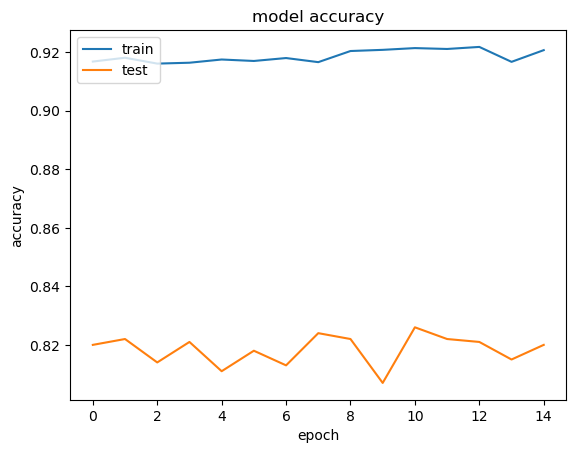

In [118]:
import matplotlib.pyplot as plt
%matplotlib inline
print(history.history.keys())
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

In [119]:
model.save("L:\\Workspace\\Models\\bibi_qna_chatbot.h5")

In [120]:
pred_res = model.predict(([input_test, que_test]))

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step  


In [121]:
test_data[0]

(['Mary',
  'got',
  'the',
  'milk',
  'there',
  '.',
  'John',
  'moved',
  'to',
  'the',
  'bedroom',
  '.'],
 ['Is', 'John', 'in', 'the', 'kitchen', '?'],
 'no')

In [122]:
pred_res

array([[6.3044382e-08, 1.5729684e-03, 7.4403125e-08, ..., 6.4793277e-08,
        6.1173054e-08, 7.3824964e-08],
       [2.5502409e-08, 6.8758512e-03, 2.7200196e-08, ..., 2.6283454e-08,
        2.4638565e-08, 2.8411224e-08],
       [1.0223878e-06, 7.2321236e-01, 1.0168220e-06, ..., 9.2161520e-07,
        9.6120402e-07, 1.0102791e-06],
       ...,
       [1.6851054e-07, 7.8044471e-04, 1.6472228e-07, ..., 1.7185313e-07,
        1.2259893e-07, 1.6180563e-07],
       [4.3340691e-08, 8.8932019e-01, 4.1053248e-08, ..., 4.4778265e-08,
        4.3535227e-08, 4.2702464e-08],
       [3.6349579e-10, 9.9851233e-01, 2.9470718e-10, ..., 3.2336955e-10,
        3.1860767e-10, 3.0797401e-10]], dtype=float32)

In [123]:
pred_res.shape

(1000, 38)

In [124]:
pred_res[0] #- probabilities of every 38 word for 1 of 1000 test data

array([6.3044382e-08, 1.5729684e-03, 7.4403125e-08, 4.6998558e-08,
       5.9285753e-08, 5.0260873e-08, 7.4784857e-08, 6.2012425e-08,
       5.7180525e-08, 4.8919912e-08, 6.0762446e-08, 4.7339082e-08,
       7.3228662e-08, 6.4018749e-08, 6.4871678e-08, 6.6079522e-08,
       6.5694351e-08, 5.3326779e-08, 6.7138558e-08, 6.0530290e-08,
       5.0017775e-08, 6.2708352e-08, 7.4863351e-08, 5.9343677e-08,
       6.1872541e-08, 5.9855907e-08, 5.7372581e-08, 7.1621741e-08,
       6.0135115e-08, 5.2919763e-08, 5.7341946e-08, 7.2650884e-08,
       9.9842477e-01, 5.4385197e-08, 6.0481582e-08, 6.4793277e-08,
       6.1173054e-08, 7.3824964e-08], dtype=float32)

In [125]:
pred_res_idx = [x.argmax() for x in pred_res]
pred_res_idx

[np.int64(32),
 np.int64(32),
 np.int64(1),
 np.int64(32),
 np.int64(1),
 np.int64(32),
 np.int64(32),
 np.int64(1),
 np.int64(32),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(32),
 np.int64(32),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(32),
 np.int64(32),
 np.int64(1),
 np.int64(32),
 np.int64(1),
 np.int64(32),
 np.int64(32),
 np.int64(1),
 np.int64(1),
 np.int64(32),
 np.int64(32),
 np.int64(1),
 np.int64(1),
 np.int64(32),
 np.int64(32),
 np.int64(1),
 np.int64(1),
 np.int64(32),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(32),
 np.int64(1),
 np.int64(32),
 np.int64(32),
 np.int64(32),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(32),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(32),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(32),
 np.int64(32),
 np.int64(1),
 np.int64(32),
 np.int64(1),
 np.int64(32),
 np.int64(32),
 np.int64(1),
 np.int64(32),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(32),
 np

In [136]:
val_max = np.argmax(pred_res[0])
for val,key in tokenizer.word_index.items():
    if val == val_max:
        k = key

k

'yes'

In [129]:
pred_res[0][val_max]

np.float32(0.99842477)

In [161]:
test_data[0]

(['Mary',
  'got',
  'the',
  'milk',
  'there',
  '.',
  'John',
  'moved',
  'to',
  'the',
  'bedroom',
  '.'],
 ['Is', 'John', 'in', 'the', 'kitchen', '?'],
 'no')

In [151]:
# I was doing a mistkae. I was checking the val_max with val - but the val is value, not key. 
# I need to check val_max - that is index, with key. 
val_max = np.argmax(pred_res[1])
for val,key in tokenizer.word_index.items():
    if key == val_max:
        k = val
print(k)

no


In [153]:
pred_results_test = []
i = 0
for s,q,a in test_data:
    val_max = np.argmax(pred_res[i])
    for val, key in tokenizer.word_index.items():
        if key == val_max:
            pred_results_test.append(val)
    i += 1

In [156]:
len(pred_results_test)

1000

In [163]:
test_ans_two = [ans for s,q,ans in test_data]
# test_ans_two

In [167]:
def check_acc(test, pred):
    res = 0
    false = 0
    for i in range(len(test)):
        if test[i]==pred[i]:
            res += 1
        else:
            return i
    print(false)
    return ((res/1000) * 100 )

In [168]:
check_acc(test_ans_two, pred_results_test)

3

In [171]:
test_data[3]

(['Mary',
  'got',
  'the',
  'milk',
  'there',
  '.',
  'John',
  'moved',
  'to',
  'the',
  'bedroom',
  '.',
  'Mary',
  'discarded',
  'the',
  'milk',
  '.',
  'John',
  'went',
  'to',
  'the',
  'garden',
  '.',
  'Daniel',
  'moved',
  'to',
  'the',
  'bedroom',
  '.',
  'Daniel',
  'went',
  'to',
  'the',
  'garden',
  '.',
  'Daniel',
  'travelled',
  'to',
  'the',
  'bathroom',
  '.',
  'Sandra',
  'travelled',
  'to',
  'the',
  'bedroom',
  '.'],
 ['Is', 'Daniel', 'in', 'the', 'bathroom', '?'],
 'yes')

In [172]:
pred_results_test[3]

'no'

In [192]:
my_story = "John left the kitchen . Sandra dropped the football in the bedroom ."

In [174]:
vocab

{'.',
 '?',
 'Daniel',
 'Is',
 'John',
 'Mary',
 'Sandra',
 'apple',
 'back',
 'bathroom',
 'bedroom',
 'discarded',
 'down',
 'dropped',
 'football',
 'garden',
 'got',
 'grabbed',
 'hallway',
 'in',
 'journeyed',
 'kitchen',
 'left',
 'milk',
 'moved',
 'no',
 'office',
 'picked',
 'put',
 'the',
 'there',
 'to',
 'took',
 'travelled',
 'up',
 'went',
 'yes'}

In [193]:
my_question = "Is the football in the garden ?"

In [194]:
my_data_new = [(my_story.split(), my_question.split(), 'yes')]

In [195]:
my_data_new

[(['John',
   'left',
   'the',
   'kitchen',
   '.',
   'Sandra',
   'dropped',
   'the',
   'football',
   'in',
   'the',
   'bedroom',
   '.'],
  ['Is', 'the', 'football', 'in', 'the', 'garden', '?'],
  'yes')]

In [196]:
my_story, my_ques, my_ans = vectorize_stories(my_data_new)

In [197]:
my_pred = model.predict(([my_story, my_ques]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


In [198]:
val_max = np.argmax(my_pred[0])

In [199]:
for key, val in tokenizer.word_index.items():
    if val == val_max:
        k = key 

print(k)

no


In [200]:
my_pred[0][val_max]

np.float32(0.9960188)